In [1]:
from dataclasses import dataclass
from pathlib import Path
import os
import math
from pprint import pprint

import cv2
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
import pillow_heif
pillow_heif.register_heif_opener() # Register HEIF opener to allow PIL to read HEIC files

In [2]:
Path.cwd()

WindowsPath('c:/Proyectos/KINECTRICS/Anomaly-Detection/notebooks')

In [3]:
#-------------------------------------------------------------------------------
# Paths
#-------------------------------------------------------------------------------
DATA_DIR = Path("../data/data_raw").resolve()
print(DATA_DIR)

#-------------------------------------------------------------------------------
# Constants
#-------------------------------------------------------------------------------
VALID_EXTS = {".jpg", ".jpeg", ".png", ".heic", ".bmp", ".tiff"}

C:\Proyectos\KINECTRICS\Anomaly-Detection\data\data_raw


In [4]:
@dataclass
class PreprocessConfig:
    output_size: tuple[int, int] = (512, 512)
    padding_color: tuple[int, int, int] = (235, 235, 235)
    crop_margin_ratio: float = 0.08
    canny_threshold1: int = 50
    canny_threshold2: int = 150
    morph_kernel_size: int = 9
    min_component_area_ratio: float = 0.01
    hough_threshold: int = 80
    hough_min_line_length_ratio: float = 0.15
    hough_max_line_gap: int = 20
    debug: bool = True

---
# Loading Data → Saving new Data
---

### List all the available images in the given folder:

In [5]:
def list_files(directory: Path) -> list[Path]:
    """ Returns the list of paths of all the images in the given directory and subdirectories. """
    files = []
    for root, dirs, filenames in os.walk(directory):
        for fl in filenames:
            if Path(fl).suffix.lower() not in VALID_EXTS: # skip non-image files
                continue
            files.append(Path(root) / fl)
    files.sort()
    return files

data_images = list_files(DATA_DIR)
print(f"Found {len(data_images)} images in {DATA_DIR}.\n")
pprint(data_images[ : 5])
print()

clean_v1 = list_files(DATA_DIR / "clean_v1")
print(f"Found {len(clean_v1)} images in {DATA_DIR / 'clean_v1'}.\n")
pprint(clean_v1[ : 5])

Found 724 images in C:\Proyectos\KINECTRICS\Anomaly-Detection\data\data_raw.

[WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data/data_raw/clean_v1/IMG_0595.HEIC'),
 WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data/data_raw/clean_v1/IMG_0596.HEIC'),
 WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data/data_raw/clean_v1/IMG_0597.HEIC'),
 WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data/data_raw/clean_v1/IMG_0598.HEIC'),
 WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data/data_raw/clean_v1/IMG_0599.HEIC')]

Found 58 images in C:\Proyectos\KINECTRICS\Anomaly-Detection\data\data_raw\clean_v1.

[WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data/data_raw/clean_v1/IMG_0595.HEIC'),
 WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data/data_raw/clean_v1/IMG_0596.HEIC'),
 WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data/data_raw/clean_v1/IMG_0597.HEIC'),
 WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data/data_r

## Convert to a readable format for opencv, and standardize orientation:
- HEIC/HEIF: Standard OpenCV builds often lack native support for Apple's High Efficiency formats without external libraries.

<span style='color:red'> Note: </span> If `imread()` fails to read a file, it will return an **empty matrix** (None) rather than throwing an error.

In [6]:
def _convert_image_format(path: Path, dataset_root: Path, ext: str) -> tuple[Path, Path]:
    """ Convert an image to a new format and standardize orientation.
    Save results in a sibling dataset folder, preserving its internal structure. 
    
    Example:
        dataset_root = data/
        path = data/clean_v1/set_a/img1.heic"
        ext = "jpg"
    Output:
        data_jpg/clean_v1/set_a/img1.jpg
    """
    ext = ext.lstrip(".").lower() # clean extension, e.g. "jpg" instead of ".JPG"
    dataset_root = dataset_root.resolve()
    path = path.resolve()
    
    relative_path = path.relative_to(dataset_root)                     # e.g. clean_v1/set_a/img1.heic
    output_root = dataset_root.parent / f"{dataset_root.name}_{ext}"   # e.g. data_jpg
    output_file = (output_root / relative_path).with_suffix(f".{ext}") # e.g. data_jpg/clean_v1/set_a/img1.jpg
    
    output_file.parent.mkdir(exist_ok=True, parents=True)
    
    with Image.open(path) as img: # Decodes the image using PIL, which supports HEIC format thanks to pillow_heif
        if not output_file.exists():
            # Landscape orientation, rotate to portrait:
            w, h = img.size
            if w > h:
                img = np.array(img) # Convert PIL image to NumPy array for OpenCV processing
                img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
                img = Image.fromarray(img) # Convert back to PIL image for saving
                
            img.save(output_file) # Encodes the image in the new format and saves it to the output file
    
    return output_file, output_root

In [7]:
def convert_dataset_images(dataset_root: Path, ext: str) -> tuple[list[Path], Path]:
    """ Convert all images in a dataset to a new format. Return the list of 
    output paths and the output folder. """
    
    input_files = list_files(dataset_root)
    output_files = []
    output_folder = None
    errors = 0
    
    for path in input_files:
        try:
            output_file, output_folder = _convert_image_format(path, dataset_root, ext)
            output_files.append(output_file)
        except Exception as e:
            print(f"Error converting {path}: {e}")
            errors += 1
            
    print('\n' + '-'*80 + f'\nFailed to convert {errors} files.' if errors > 0 else 'All files converted successfully.')
    return output_files, output_folder

In [8]:
data_jpg, output_folder_jpg = convert_dataset_images(DATA_DIR, "jpg")

Error converting C:\Proyectos\KINECTRICS\Anomaly-Detection\data\data_raw\underwater\BundleCollage.png: Image size (425002074 pixels) exceeds limit of 178956970 pixels, could be decompression bomb DOS attack.
Error converting C:\Proyectos\KINECTRICS\Anomaly-Detection\data\data_raw\underwater\ElementCollage El1.png: Image size (242702234 pixels) exceeds limit of 178956970 pixels, could be decompression bomb DOS attack.

--------------------------------------------------------------------------------
Failed to convert 2 files.


In [9]:
print(f"{len(data_jpg)} images converted and stored in {output_folder_jpg}.\n")
pprint(data_jpg[ : 5])
print()

722 images converted and stored in C:\Proyectos\KINECTRICS\Anomaly-Detection\data\data_raw_jpg.

[WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data/data_raw_jpg/clean_v1/IMG_0595.jpg'),
 WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data/data_raw_jpg/clean_v1/IMG_0596.jpg'),
 WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data/data_raw_jpg/clean_v1/IMG_0597.jpg'),
 WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data/data_raw_jpg/clean_v1/IMG_0598.jpg'),
 WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data/data_raw_jpg/clean_v1/IMG_0599.jpg')]



## Resize and pad images to a fixed size, preserving aspect ratio:

In [10]:
def _resize_with_padding(image: np.ndarray,
                        size: tuple[int, int] = (256, 256),
                        pad_color: int | tuple[int, int, int] = 0) -> np.ndarray:
    '''
    Resize image preserving aspect ratio and pad to target size.
    
    Args:
        image: RGB image
        size: target (height, width)
        pad_color: padding value (int for gray, tuple for RGB)
    
    Returns:
        image resized to (H, W) with padding
    '''
    
    h, w, _ = image.shape
    target_h, target_w = size
    
    # escala manteniendo aspect ratio
    scale = min(target_h / w, target_w / h)
    
    new_w = int(w * scale)
    new_h = int(h * scale)
    
    # resize
    resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)
    
    # crear canvas
    if isinstance(pad_color, int):
        pad_color = (pad_color, pad_color, pad_color)
    
    canvas = np.full((target_h, target_w, 3), pad_color, dtype=image.dtype) # uniform background.
    
    # centrar
    x_offset = (target_w - new_w) // 2
    y_offset = (target_h - new_h) // 2
    
    canvas[y_offset:y_offset + new_h, x_offset:x_offset + new_w] = resized
    
    return canvas

In [11]:
def _resize_image_format(path: Path,
                        dataset_root: Path,
                        size: tuple[int, int] =(256, 256),
                        pad_color: int | tuple[int, int, int] = 0) -> tuple[Path, Path]:
    ''' Resize an image to a target size with padding.
    Save results in a sibling dataset folder, preserving its internal structure. 
    
    Example:
        dataset_root = data/
        path = data/clean_v1/set_a/img1.jpg"
    Output:
        data_256x256/clean_v1/set_a/img1.jpg '''
    
    dataset_root = dataset_root.resolve()
    path = path.resolve()
    
    relative_path = path.relative_to(dataset_root)              # e.g. clean_v1/set_a/img1.jpg
    output_root = (dataset_root.parent / 
                   f"{dataset_root.name}_{size[0]}x{size[1]}")  # e.g. data_256x256
    output_file = (output_root / relative_path)                 # e.g. data_256x256/clean_v1/set_a/img1.jpg
    
    output_file.parent.mkdir(exist_ok=True, parents=True)
    
    if not output_file.exists():
        img = cv2.imread(str(path)) # Read the image using OpenCV, which is faster for resizing and padding operations
        
        if img is not None:
            resize = _resize_with_padding(img, size=size, pad_color=pad_color)
            cv2.imwrite(str(output_file), resize)
        else:
            print(f"Error reading {path}.")
    
    return output_file, output_root

In [12]:
def resize_dataset_images(dataset_root: Path,
                          size: tuple[int, int] =(256, 256),
                          pad_color: int | tuple[int, int, int] = 0) -> tuple[list[Path], Path]:
    """ Resize all images in a dataset. Return the list of output paths and the output folder. """
    input_files = list_files(dataset_root)
    output_files = []
    output_folder = None
    errors = 0
    
    for path in input_files:
        try:
            output_file, output_folder = \
            _resize_image_format(path, dataset_root, size=size, pad_color=pad_color)
            output_files.append(output_file)
        except Exception as e:
            print(f"Error converting {path}: {e}")
            errors += 1
            
    print('\n' + '-'*80 + f'\nFailed to resize {errors} files.' if errors > 0 else 'All files resized successfully.')
    return output_files, output_folder

In [13]:
data_jpg_256, output_folder_jpg_256 = resize_dataset_images(output_folder_jpg, size=(256, 256), pad_color=200)

All files resized successfully.


In [14]:
print(f"{len(data_jpg_256)} images resized and stored in {output_folder_jpg_256}.\n")
pprint(data_jpg_256[ : 5])
print()

722 images resized and stored in C:\Proyectos\KINECTRICS\Anomaly-Detection\data\data_raw_jpg_256x256.

[WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data/data_raw_jpg_256x256/clean_v1/IMG_0595.jpg'),
 WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data/data_raw_jpg_256x256/clean_v1/IMG_0596.jpg'),
 WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data/data_raw_jpg_256x256/clean_v1/IMG_0597.jpg'),
 WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data/data_raw_jpg_256x256/clean_v1/IMG_0598.jpg'),
 WindowsPath('C:/Proyectos/KINECTRICS/Anomaly-Detection/data/data_raw_jpg_256x256/clean_v1/IMG_0599.jpg')]



---
# Image processing:
---

OpenCV follows this pattern:
 - imread → needs how to read the image code `IMREAD_*`
 - cvtColor → needs color conversion code `COLOR_*`
 
**Flags** = Predefined CONSTANTS (numbers) to control how data is read or processed by OpenCV. Common flags include:

`img = cv2.imread(path, flag)`
- `cv2.IMREAD_COLOR`: Reads the image in color (default).
- `cv2.IMREAD_GRAYSCALE`: Reads the image in grayscale.
- `cv2.IMREAD_UNCHANGED`: Reads the image as is, including alpha channel if present.


`img_rgb = cv2.cvtColor(img, flag)`
- `cv2.COLOR_BGR2RGB`: Converts an image from BGR color space (used by OpenCV) to RGB color space (used by Matplotlib and PIL).
- `cv2.COLOR_RGB2BGR`: Converts an image from RGB color space (used by Matplotlib and PIL) to BGR color space (used by OpenCV).
- `cv2.COLOR_GRAY2BGR`: Converts a grayscale image to 3 channels (e.g., when a model expects 3 channels).
---

In [15]:
# Example:
cv2.COLOR_BGR2RGB

4

Auxiliar functions for visualization...

In [39]:
def plot_image(image: np.ndarray, 
               title: str = "", cmap: str | None = None, 
               figsize: tuple[int, int] | None = None) -> None:
    
    plt.figure(figsize=figsize)
    plt.title(title)
    plt.axis("off")
    plt.imshow(image, cmap=cmap)
    plt.show()

#-------------------------------------------------------------------------------

def plot_gray(image_gray: np.ndarray, 
              title: str = "", 
              figsize: tuple[int, int] | None = None) -> None:
    
    plot_image(image_gray, title=title, cmap="gray", figsize=figsize)
    
#-------------------------------------------------------------------------------

def plot_multi(shape: tuple[int, int],
               images: list[np.ndarray],
               titles: list[str] | None = None, 
               cmap: str | None = None, 
               figsize: tuple[int, int] | None = None) -> None:
    
    n = len(images)
    if titles is not None and len(titles) != n:
        raise ValueError("Length of titles must match number of images.")
    
    fig, axs = plt.subplots(*shape, figsize=figsize)
    
    try:
        axs = axs.flatten() # Flatten axes if it's a 2D array, so it can be iterated in a single loop
    except:
        raise ValueError("Shape must be at least more than (1, 1).")
    
    titles = titles if titles is not None else [f"Image {i+1}" for i in range(n)]
    for ax, img, tit in zip(axs, images, titles):
        ax.axis('off')
        ax.set_title(tit)
        ax.imshow(img, cmap=cmap)
    plt.tight_layout()
    plt.show()

### Load and display an example image

 Image size: (256, 256, 3)


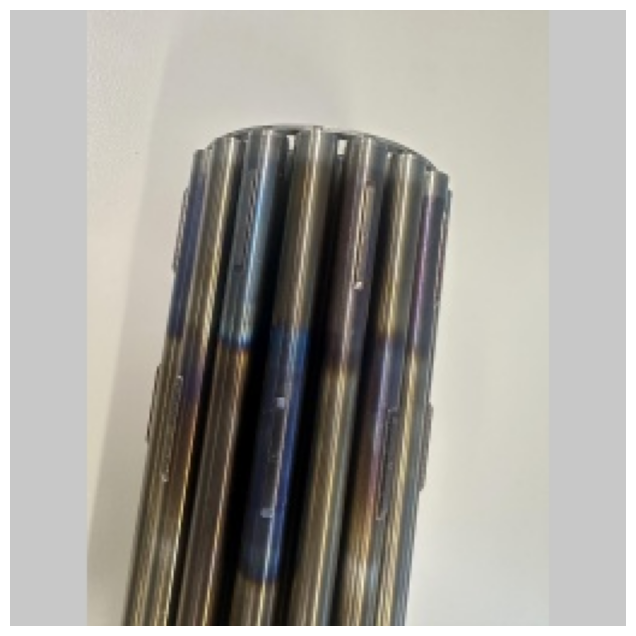

In [17]:
def load_image_rgb(image_path: Path) -> np.ndarray:
    ''' Load an image and convert it to RGB. '''
    image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    if image is None:
        raise FileNotFoundError(f"Image at {image_path} could not be loaded.")
    return image

im_path = str(data_jpg_256[5])
im_rgb = load_image_rgb(im_path)

print(f' Image size: {im_rgb.shape}')
plot_image(im_rgb, figsize=(8, 8))

In [18]:
def rgb_to_gray(image_rgb: np.ndarray) -> np.ndarray:
    ''' Convert an RGB image to grayscale. '''
    return cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

im_gray = rgb_to_gray(im_rgb)
print(f' Image size: {im_gray.shape}')


 Image size: (256, 256)


<span style='color:red'> Note: </span> When `Matplotlib` plots an image with only one channel, it treats the data as a **2D array of intensities** rather than a direct color image. By default, it applies a color map (`'viridis'`) to map those intensity values to a spectrum of colors, which is why single-channel images often appear in shades of purple and yellow instead of grayscale

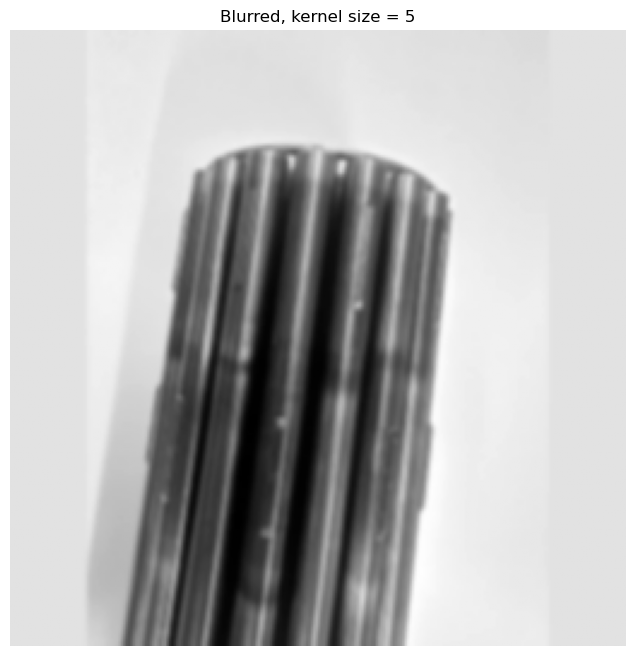

In [19]:
def blur_image(image: np.ndarray, kernel_size: int = 5) -> np.ndarray:
    ''' Apply Gaussian blur to the image. '''
    return cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)

im_blurred = blur_image(im_gray)

plot_gray(im_blurred, title='Blurred, kernel size = 5', figsize=(8, 8))

Just to visualize the thresholds before applying Canny edge detection...

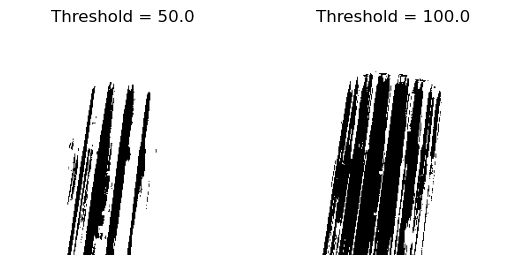

In [20]:
T1, im_thresh_low = cv2.threshold(im_gray, 50, 255, cv2.THRESH_BINARY)
T2, im_thresh_high = cv2.threshold(im_gray, 100, 255, cv2.THRESH_BINARY)

fig, axs = plt.subplots(1, 2)
titles = [f'Threshold = {T1}', f'Threshold = {T2}']
imgs = [im_thresh_low, im_thresh_high]
for ax, imgs, tit in zip(axs, imgs, titles):
    ax.axis('off')
    ax.set_title(tit)
    ax.imshow(imgs, cmap='gray')

plt.show()

### Find and close broken edges:

**dilation**: 
- If there is at least one white pixel in the kernel → the center pixel turns white.

**erosion**: 
- If all the pixels in the kernel are white → the center pixel remains white. 
- If not → it turns black.

The kernel is a <span style='color:yellow'> unitary matrix. </span> The values doesn't matter as in a convolution, what matters is the **shape and the size.**

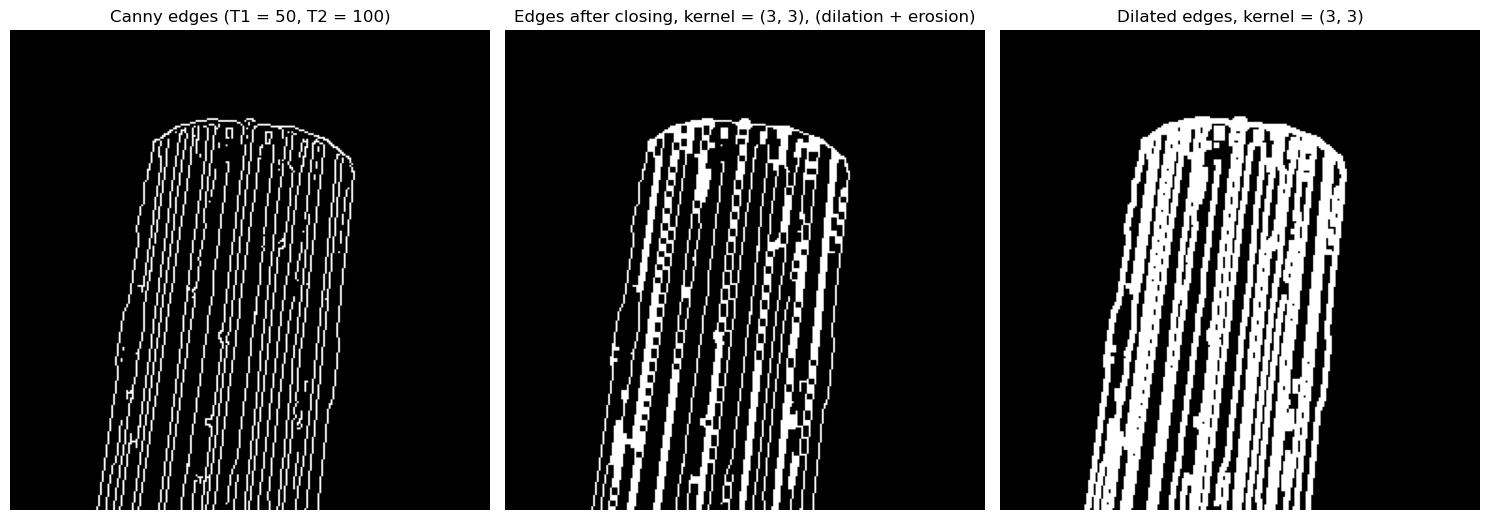

In [21]:
def get_edges(image: np.ndarray, T1: int, T2: int) -> np.ndarray:
    ''' Return a binary image where the edges are highlighted, using Canny edge detection. '''
    return cv2.Canny(image, threshold1=T1, threshold2=T2)

def close_edges(image: np.ndarray, kernel_size: tuple[int, int] = (3, 3)) -> np.ndarray:
    ''' Close the edges of the image using a morphological operation, dilation + erosion. '''
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernel_size)
    return cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel) # (dilation + erosion)

def dilation(image: np.ndarray, kernel_size: tuple[int, int] = (3, 3)) -> np.ndarray:
    ''' Dilate the image using a morphological operation. '''
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernel_size)
    return cv2.dilate(image, kernel)


edges = get_edges(im_blurred, 50, 100)
close = close_edges(edges, kernel_size=(3, 3))
dilated = dilation(close, kernel_size=(3, 3))

fig, axs = plt.subplots(1, 3, figsize=(15, 10))
images = [edges, close, dilated]
titles = ["Canny edges (T1 = 50, T2 = 100)", "Edges after closing, kernel = (3, 3), (dilation + erosion)", "Dilated edges, kernel = (3, 3)"]
for ax, imgs, tit in zip(axs, images, titles):
    ax.axis('off')
    ax.set_title(tit)
    ax.imshow(imgs, cmap='gray')

plt.tight_layout()
plt.show()

### Find contours:

Found 55 contours.
Found 99 contours.
Found 134 contours.


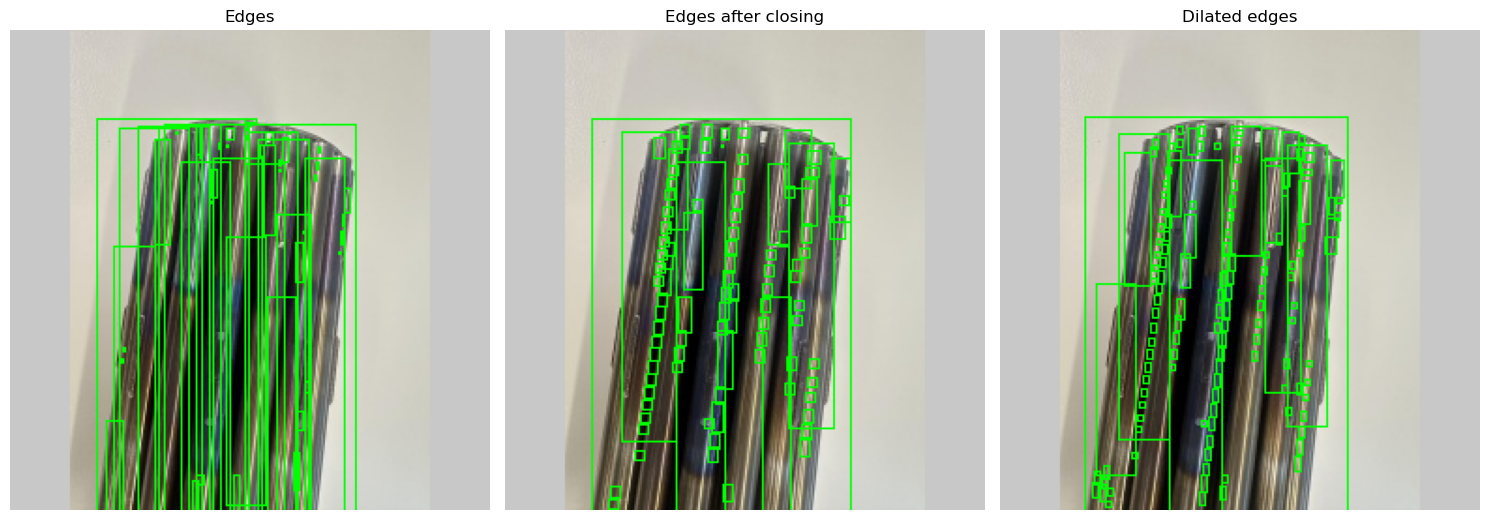

In [ ]:
def find_boxes_contours(image_rgb: np.ndarray, image_edges: np.ndarray) -> np.ndarray:
    contours, hierarchy = cv2.findContours(image_edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    print(f"Found {len(contours)} contours.")
    
    image_boxes = image_rgb.copy()
    
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(image_boxes, (x, y), (x + w, y + h), (0, 255, 0), 1)
    
    return image_boxes



im_edges_boxes = find_boxes_contours(im_rgb, edges)
im_close_boxes = find_boxes_contours(im_rgb, close)
im_dilated_boxes = find_boxes_contours(im_rgb, dilated)

images = [im_edges_boxes, im_close_boxes, im_dilated_boxes]
titles = ["Edges", "Edges after closing", "Dilated edges"]

plot_multi(shape=(1, 3), images=images, titles=titles, figsize=(15, 10))